# Fixed D, M / Vary N (Finite-M, softmax attention)

`exp_fixed_DM_vary_N_dynamics_softmax.ipynb` の **M固定・N変動** を明示した複製版。

In [25]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ==================================
# Simple finite-M dynamics experiment
# (fixed D, M; vary N)
# softmax attention + data-only/history mask
# ==================================
D = 100
M = 20000
N_LIST = [10, 100, 1000]

BATCH_SIZE = 300
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.001
ITERATIONS = 2000
EVAL_T_LIST = list(range(0, 20))
EVAL_BATCH_SIZE = 4096
SEED = 941
N_TRIALS = 1  # 同一設定での繰り返し回数（SE算出用）

# 推論時の拡張設定
# - True : [w0, w1, ..., wt] を build_Z に渡して履歴を積む
# - False: 毎 step で 1-token のみ
USE_HISTORY_AT_INFERENCE = True
# マスク方式
# - "data_only"  : 最後 token は example token のみ参照（指定方式）
# - "history_cot": 最後 token は example + 過去 estimate token を参照（self のみ遮断）
ATTN_MASK_MODE = "history_cot"

DE = 2 * D + 2


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"device={device}, D={D}, M={M}, N_LIST={N_LIST}, "
    f"B={BATCH_SIZE}, iters={ITERATIONS}, lr={ADAM_LR}, l2={PARAM_L2_LAMBDA}, "
    f"trials={N_TRIALS}"
)


def sample_task_batch(batch_size, n, d=D, device=device):
    x = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, x)
    return x, y, w_star


def build_fixed_train_dataset(m, n):
    x, y, w_star = sample_task_batch(m, n=n)
    return {"X": x, "y": y, "w_star": w_star, "M": m, "N": n}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    return train_data["X"][idx], train_data["y"][idx], train_data["w_star"][idx]


def sample_w0_random(x, d=D, device=device):
    return torch.randn(x.shape[0], d, device=device)


def build_Z(x, y, w_prefix):
    b, d, n = x.shape
    i = len(w_prefix) - 1
    t = n + i + 1
    z = torch.zeros(b, DE, t, device=x.device)
    z[:, :d, :n] = x
    z[:, d, :n] = y
    for step, w_t in enumerate(w_prefix):
        z[:, d + 1 : d + 1 + d, n + step] = w_t
    z[:, -1, :] = 1.0
    return z


def build_attn_mask(T, L, device, mode="data_only"):
    # 共通初期化（指定方式）
    attn_mask = torch.zeros(T, T, device=device)

    if mode == "data_only":
        # attn_mask[-1, L:] = -inf
        attn_mask[-1, L:] = float("-inf")
    elif mode == "history_cot":
        # self のみ遮断（example + 過去 estimate は参照可）
        attn_mask[-1, T - 1] = float("-inf")
    else:
        raise ValueError(f"Unknown mask mode: {mode}")

    return attn_mask


def f_softmax_last(z, v, w, n, mask_mode="data_only"):
    B, de, T = z.shape
    z_last = z[:, :, -1]

    # bilinear score: z_t^T W z_last
    wz_last = torch.einsum("ij,bj->bi", w, z_last)
    logits = torch.einsum("bdt,bd->bt", z, wz_last) / np.sqrt(de)

    attn_mask = build_attn_mask(T=T, L=n, device=z.device, mode=mask_mode)
    logits = logits + attn_mask[-1].unsqueeze(0)

    attn = torch.softmax(logits, dim=-1)
    weighted = torch.einsum("bdt,bt->bd", z, attn)

    out_last = z_last + torch.einsum("ij,bj->bi", v, weighted)
    return out_last


def no_cot_train_loss(v, w, x, y, w_star):
    n = x.shape[2]
    w0 = sample_w0_random(x, D, x.device)
    z0 = build_Z(x, y, [w0])
    pred = f_softmax_last(z0, v, w, n=n, mask_mode="data_only")
    w_hat = pred[:, D + 1 : D + 1 + D]
    return ((w_hat - w_star) ** 2).sum(dim=1).mean()


def eval_dynamics_curve(
    v,
    w,
    n,
    t_list,
    batch_size=EVAL_BATCH_SIZE,
    use_history=USE_HISTORY_AT_INFERENCE,
    mask_mode=ATTN_MASK_MODE,
):
    x, y, w_star = sample_task_batch(batch_size, n=n)
    with torch.no_grad():
        w_hat = sample_w0_random(x, D, device)
        losses = {}
        losses[0] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()

        max_t = max(t_list)
        if use_history:
            w_hist = [w_hat]
            for t in range(1, max_t + 1):
                z = build_Z(x, y, w_hist)
                pred = f_softmax_last(z, v, w, n=n, mask_mode=mask_mode)
                w_hat = pred[:, D + 1 : D + 1 + D]
                losses[t] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()
                w_hist.append(w_hat)
        else:
            for t in range(1, max_t + 1):
                z = build_Z(x, y, [w_hat])
                pred = f_softmax_last(z, v, w, n=n, mask_mode=mask_mode)
                w_hat = pred[:, D + 1 : D + 1 + D]
                losses[t] = ((w_hat - w_star) ** 2).mean(dim=1).mean().item()

    return {t: losses[t] for t in t_list}


def parameter_l2_penalty(v, w):
    return v.pow(2).sum() + w.pow(2).sum()


def train_model_no_cot_finite(train_data, iterations=ITERATIONS):
    v = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    w = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([v, w], lr=ADAM_LR)

    for _ in range(iterations):
        x, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(v, w, x, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(v, w)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return v.detach(), w.detach()

device=cpu, D=100, M=20000, N_LIST=[10, 100, 1000], B=300, iters=2000, lr=0.001, l2=0.001, trials=1


In [26]:
np.random.seed(SEED)
torch.manual_seed(SEED)

results_by_n = {}
for n in N_LIST:
    trial_curves = []

    for trial in range(N_TRIALS):
        trial_seed = SEED + 1000 * trial + n
        np.random.seed(trial_seed)
        torch.manual_seed(trial_seed)

        train_data = build_fixed_train_dataset(M, n=n)
        v_tr, w_tr = train_model_no_cot_finite(train_data)
        eval_curve = eval_dynamics_curve(v_tr, w_tr, n=n, t_list=EVAL_T_LIST)
        trial_curves.append(np.array([eval_curve[t] for t in EVAL_T_LIST]))

    trial_curves = np.stack(trial_curves, axis=0)  # [trials, len(t)]
    mean_curve = trial_curves.mean(axis=0)
    if N_TRIALS > 1:
        se_curve = trial_curves.std(axis=0, ddof=1) / np.sqrt(N_TRIALS)
    else:
        se_curve = np.zeros_like(mean_curve)

    results_by_n[n] = {
        "mean": {t: float(mean_curve[i]) for i, t in enumerate(EVAL_T_LIST)},
        "se": {t: float(se_curve[i]) for i, t in enumerate(EVAL_T_LIST)},
        "all": trial_curves,
    }

    print(f"N={n}: done ({N_TRIALS} trials)")

N=10: done (1 trials)
N=100: done (1 trials)
N=1000: done (1 trials)


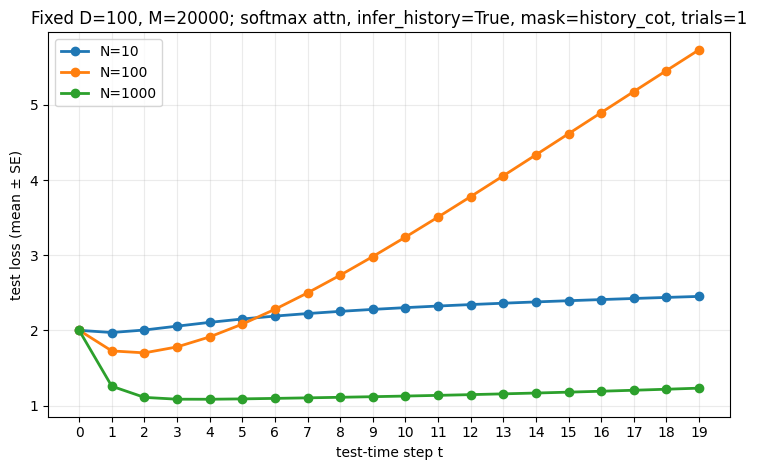

In [27]:
plt.figure(figsize=(7.5, 4.8))
for n in N_LIST:
    ts = np.array(EVAL_T_LIST)
    mean_vals = np.array([results_by_n[n]["mean"][t] for t in ts])
    se_vals = np.array([results_by_n[n]["se"][t] for t in ts])

    plt.plot(ts, mean_vals, marker="o", linewidth=2, label=f"N={n}")
    plt.fill_between(ts, mean_vals - se_vals, mean_vals + se_vals, alpha=0.18)

plt.xlabel("test-time step t")
plt.ylabel("test loss (mean ± SE)")
plt.title(
    f"Fixed D={D}, M={M}; softmax attn, infer_history={USE_HISTORY_AT_INFERENCE}, "
    f"mask={ATTN_MASK_MODE}, trials={N_TRIALS}"
)
plt.xticks(EVAL_T_LIST)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

このコードとハイパーパラメータでは、3つの学習レジーム、つまり、overthinkingと、information limitedと、success regimeが存在することを、softmax attentionで成立することが示されている。とりあえずこの結果は使えそう。